# Training Pipeline Rollout Debug

This notebook will sequentially test four experiment configurations:

- `greedy`
- `greedy_bc_pretrain` (`BC`)
- `sac_her` (`BC + SAC + HER`, no reward shaping)
- `sac_her_reward` (`BC + SAC + HER + reward shaping`)

Each pipeline will do three things:

1. Run training / evaluation once.
2. Capture a complete rollout trajectory.
3. Generate GIF, step-by-step table, and final conclusion.

All outputs will be saved to `notebooks/artifacts/training_pipeline_rollout_debug/`.

In [6]:
from __future__ import annotations

import sys
from copy import deepcopy
from pathlib import Path

from IPython.display import Image, Markdown, display

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.training import (
    capture_rollout_trace,
    load_config,
    make_pipeline_config,
    run_named_pipeline,
    save_rollout_gif,
)

import pandas as pd

## Step 1. Load the 3x3 base-derived config, decide whether to refresh hints, and create notebook overrides

Intentionally keep timesteps and demo count low for quick verification of the entire pipeline and GIF generation.

Set `NOTEBOOK_OPTIONS["refresh_hints"]` to `True` if you want this notebook to delete the current `data/raw/hints.txt` and regenerate it on the next run.


In [7]:
BASE_CONFIG = load_config(PROJECT_ROOT / "configs" / "training_pipeline_3x3.yaml")
ARTIFACT_ROOT = (
    PROJECT_ROOT / "notebooks" / "artifacts" / "training_pipeline_rollout_debug"
)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

NOTEBOOK_OPTIONS = {
    "refresh_hints": False,
}


def prepare_hint_file(base_config: dict, *, refresh_hints: bool) -> Path:
    hint_path = PROJECT_ROOT / base_config["data"]["clue_words_path"]
    hint_path.parent.mkdir(parents=True, exist_ok=True)

    if refresh_hints and hint_path.exists():
        hint_path.unlink()
        print(f"Removed existing hint file: {hint_path.relative_to(PROJECT_ROOT)}")
    elif refresh_hints:
        print(f"Hint file will be regenerated: {hint_path.relative_to(PROJECT_ROOT)}")
    elif hint_path.exists():
        print(f"Reusing existing hint file: {hint_path.relative_to(PROJECT_ROOT)}")
    else:
        print(
            f"Hint file is missing and will be generated: {hint_path.relative_to(PROJECT_ROOT)}"
        )

    return hint_path


HINTS_PATH = prepare_hint_file(
    BASE_CONFIG,
    refresh_hints=NOTEBOOK_OPTIONS["refresh_hints"],
)

COMMON_OVERRIDES = {
    "name": "training_pipeline_rollout_debug",
    "embedding": {"max_clues": 1200},
    "bc": {
        "demo_episodes": 6,
        "pretrain_epochs": 2,
        "batch_size": 32,
    },
    "training": {
        "total_timesteps": 120,
        "learning_starts": 20,
        "batch_size": 32,
        "net_arch": [128, 128],
    },
    "evaluation": {
        "episodes": 2,
        "deterministic": True,
    },
}

PIPELINES = ["greedy", "greedy_bc_pretrain", "sac_her", "sac_her_reward"]
ARTIFACT_ROOT

Reusing existing hint file: data/raw/common_words.txt


PosixPath('/Users/sungtsewu/Desktop/temp_github/Codenames-Spymaster-RL/notebooks/artifacts/training_pipeline_rollout_debug')

## Step 2. Define shared runner

The key point is that the notebook is not bound to a specific agent type. As long as the agent produced by the pipeline supports `predict(...)` or `select_action(...)`, the same process can be reused.

In [8]:
def build_summary_row(result, trace, gif_path):
    trace_summary = trace.summary()
    return {
        "pipeline": result.pipeline_name,
        "agent": result.agent_label,
        "reward_shaped_weight": result.config["reward"]["shaped_weight"],
        "demo_transitions": result.demo_transitions,
        "eval_win_rate": round(result.agent_metrics["win_rate"], 3),
        "eval_assassin_rate": round(result.agent_metrics["assassin_rate"], 3),
        "trace_steps": trace_summary["steps"],
        "trace_total_reward": round(trace_summary["total_reward"], 3),
        "trace_won": trace_summary["won"],
        "trace_assassin_hit": trace_summary["assassin_hit"],
        "gif": str(gif_path.relative_to(PROJECT_ROOT)),
    }


def run_pipeline_demo(pipeline_name: str):
    output_dir = (
        Path("notebooks")
        / "artifacts"
        / "training_pipeline_rollout_debug"
        / pipeline_name
    )
    config = make_pipeline_config(
        deepcopy(BASE_CONFIG),
        pipeline_name,
        output_dir=str(output_dir),
        extra_overrides=deepcopy(COMMON_OVERRIDES),
    )
    result = run_named_pipeline(config, pipeline_name=pipeline_name)
    trace = capture_rollout_trace(
        result.agent,
        result.runtime.rollout_env_factory,
        pipeline_name=result.pipeline_name,
        agent_label=result.agent_label,
        deterministic=config["evaluation"]["deterministic"],
    )
    gif_path = save_rollout_gif(
        trace,
        ARTIFACT_ROOT / pipeline_name / f"{pipeline_name}_rollout.gif",
        duration_ms=1200,
    )
    summary_df = pd.DataFrame([build_summary_row(result, trace, gif_path)])
    steps_df = pd.DataFrame(trace.to_rows())
    display(Markdown(f"## {result.agent_label}"))
    display(
        Markdown(
            f"Pipeline id: `{result.pipeline_name}` | reward.shaped_weight = `{config['reward']['shaped_weight']}`"
        )
    )
    display(Markdown(f"Artifacts saved to `{gif_path.relative_to(PROJECT_ROOT)}`"))
    display(Image(filename=str(gif_path)))
    display(summary_df)
    display(steps_df)
    return {
        "config": config,
        "result": result,
        "trace": trace,
        "gif_path": gif_path,
        "summary_df": summary_df,
        "steps_df": steps_df,
    }

## Step 3. Run three pipelines and view GIFs with step-by-step clue / guessed words / reward details

Each GIF step now reveals at most one new card. If one turn would normally reveal multiple cards, the notebook splits that turn into multiple consecutive steps.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Greedy

Pipeline id: `greedy` | reward.shaped_weight = `0.0`

Artifacts saved to `notebooks/artifacts/training_pipeline_rollout_debug/greedy/greedy_rollout.gif`

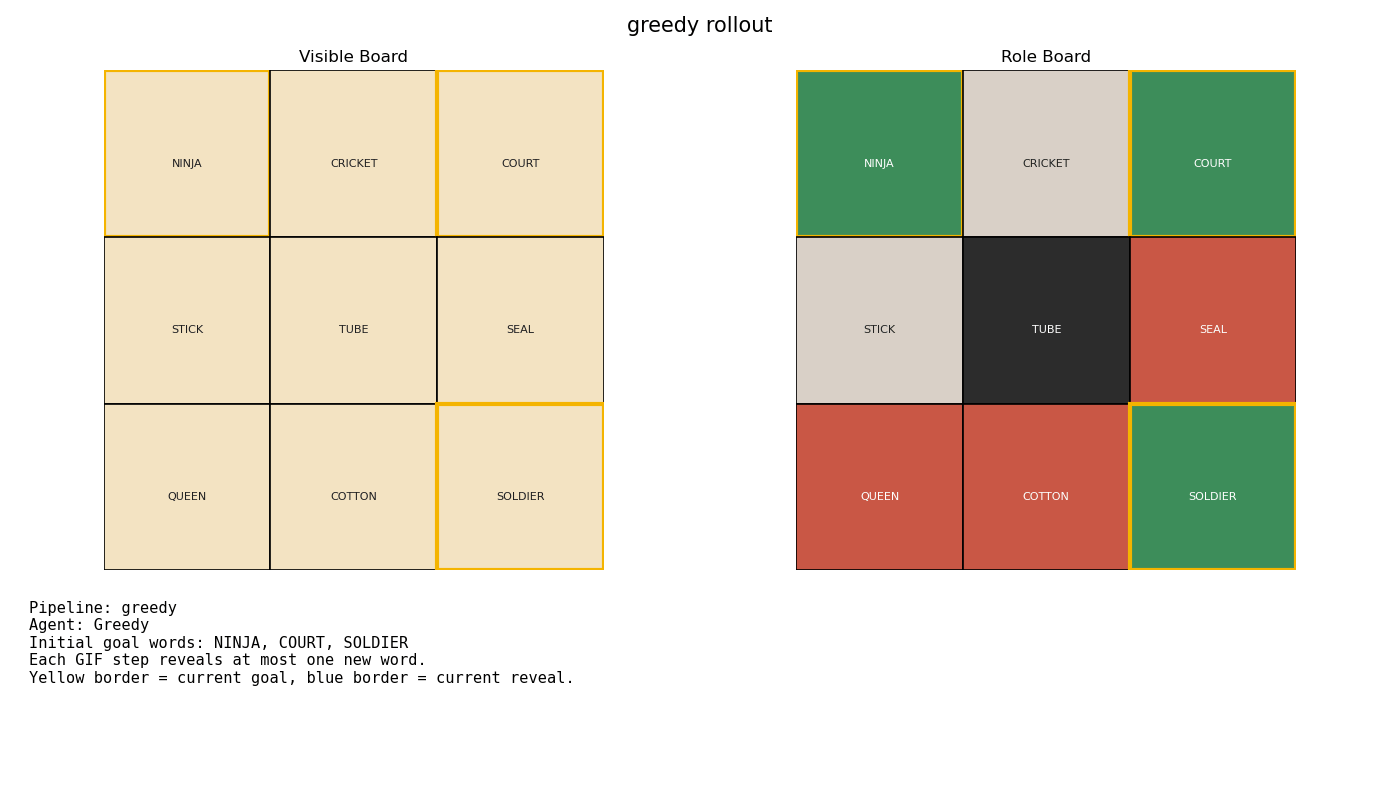

,pipeline,agent,reward_shaped_weight,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
0,greedy,Greedy,0.0,0,1.0,0.0,3,-2.0,True,False,notebooks/artifacts/training_pipeline_rollout_...


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,judge,1,"NINJA, COURT, SOLDIER",COURT,friendly,-1.0,-1.0,2,False,False
1,2,2,1,iraqi,1,"NINJA, SOLDIER",SOLDIER,friendly,-1.0,-2.0,1,False,False
2,3,3,1,muslim,1,NINJA,NINJA,friendly,0.0,-2.0,0,True,False


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## BC

Pipeline id: `greedy_bc_pretrain` | reward.shaped_weight = `0.0`

Artifacts saved to `notebooks/artifacts/training_pipeline_rollout_debug/greedy_bc_pretrain/greedy_bc_pretrain_rollout.gif`

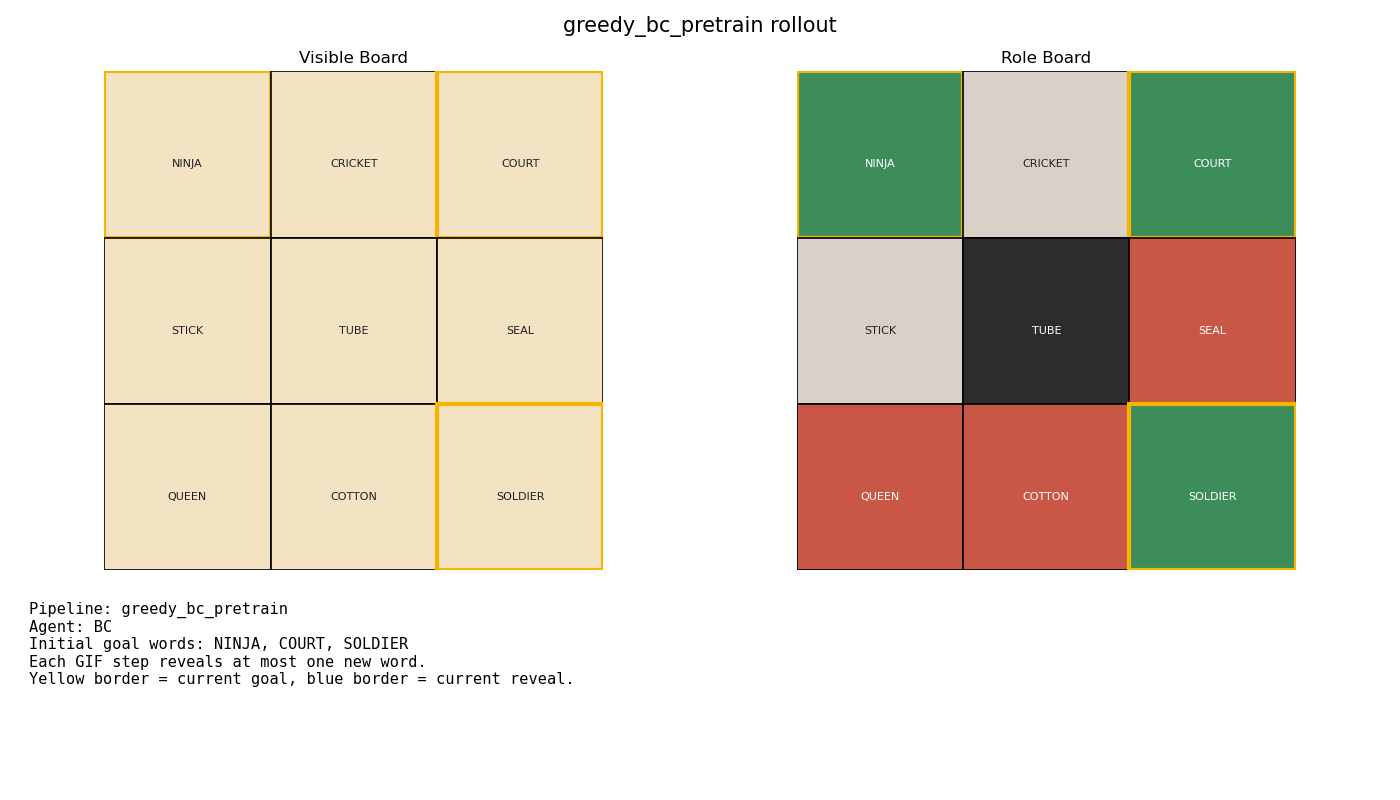

,pipeline,agent,reward_shaped_weight,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
0,greedy_bc_pretrain,BC,0.0,18,0.0,1.0,3,-43.5,False,True,notebooks/artifacts/training_pipeline_rollout_...


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,crush,5,"NINJA, COURT, SOLDIER",STICK,neutral,-2.5,-2.5,3,False,False
1,2,2,1,cocaine,5,"NINJA, COURT, SOLDIER",NINJA,friendly,0.0,-2.5,2,False,False
2,3,2,2,cocaine,5,"NINJA, COURT, SOLDIER",TUBE,assassin,-41.0,-43.5,2,False,True


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## BC + SAC + HER

Pipeline id: `sac_her` | reward.shaped_weight = `0.0`

Artifacts saved to `notebooks/artifacts/training_pipeline_rollout_debug/sac_her/sac_her_rollout.gif`

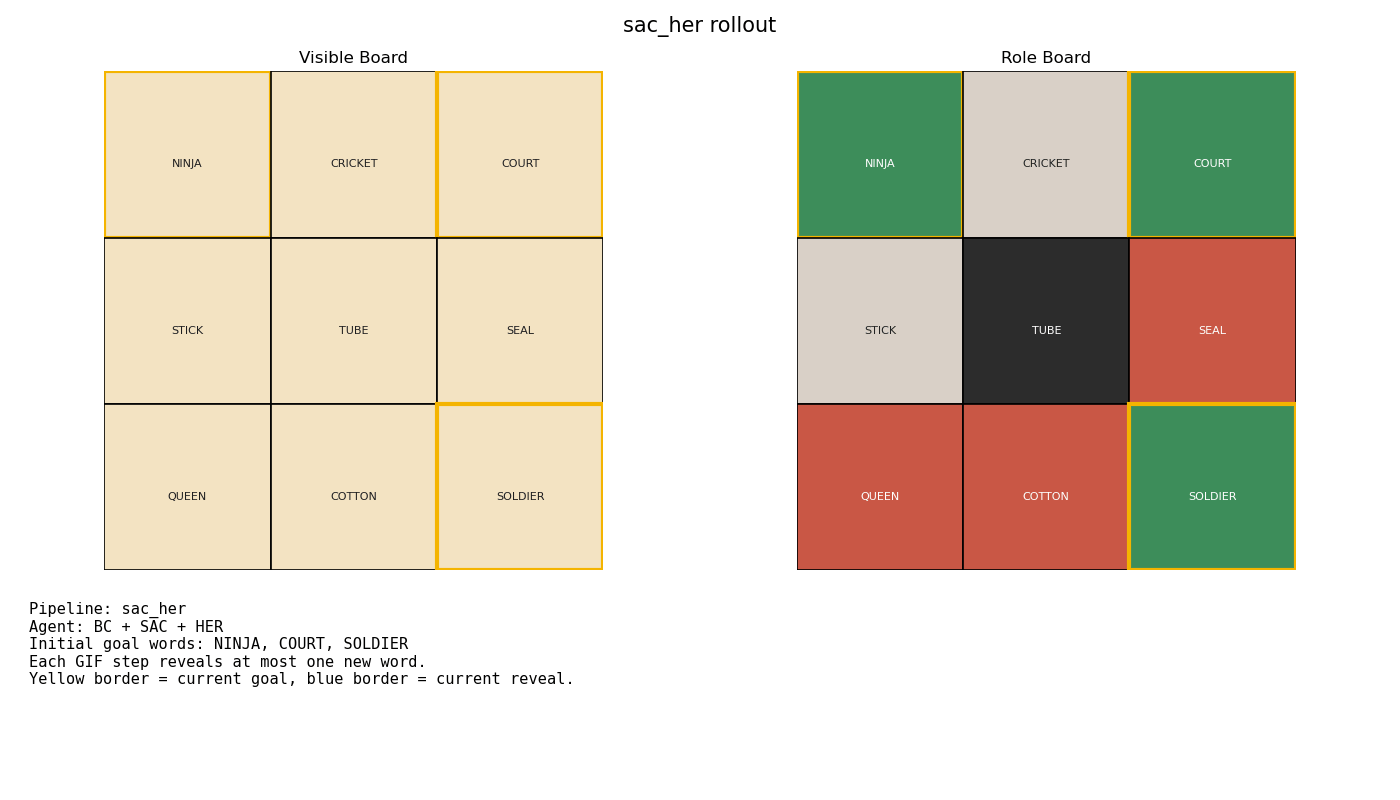

,pipeline,agent,reward_shaped_weight,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
0,sac_her,BC + SAC + HER,0.0,18,0.0,1.0,7,-57.5,False,True,notebooks/artifacts/training_pipeline_rollout_...


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,israeli,1,"NINJA, COURT, SOLDIER",SOLDIER,friendly,-1.0,-1.0,2,False,False
1,2,2,1,strict,1,"NINJA, COURT",STICK,neutral,-2.5,-3.5,2,False,False
2,3,3,1,certain,1,"NINJA, COURT",SEAL,opponent,-4.0,-7.5,2,False,False
3,4,4,1,above,1,"NINJA, COURT",NINJA,friendly,-1.0,-8.5,1,False,False
4,5,5,1,outer,1,COURT,QUEEN,opponent,-4.0,-12.5,1,False,False
5,6,6,1,other,1,COURT,COTTON,opponent,-4.0,-16.5,1,False,False
6,7,7,1,below,1,COURT,TUBE,assassin,-41.0,-57.5,1,False,True


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## BC + SAC + HER + Reward Shaping

Pipeline id: `sac_her_reward` | reward.shaped_weight = `1.0`

Artifacts saved to `notebooks/artifacts/training_pipeline_rollout_debug/sac_her_reward/sac_her_reward_rollout.gif`

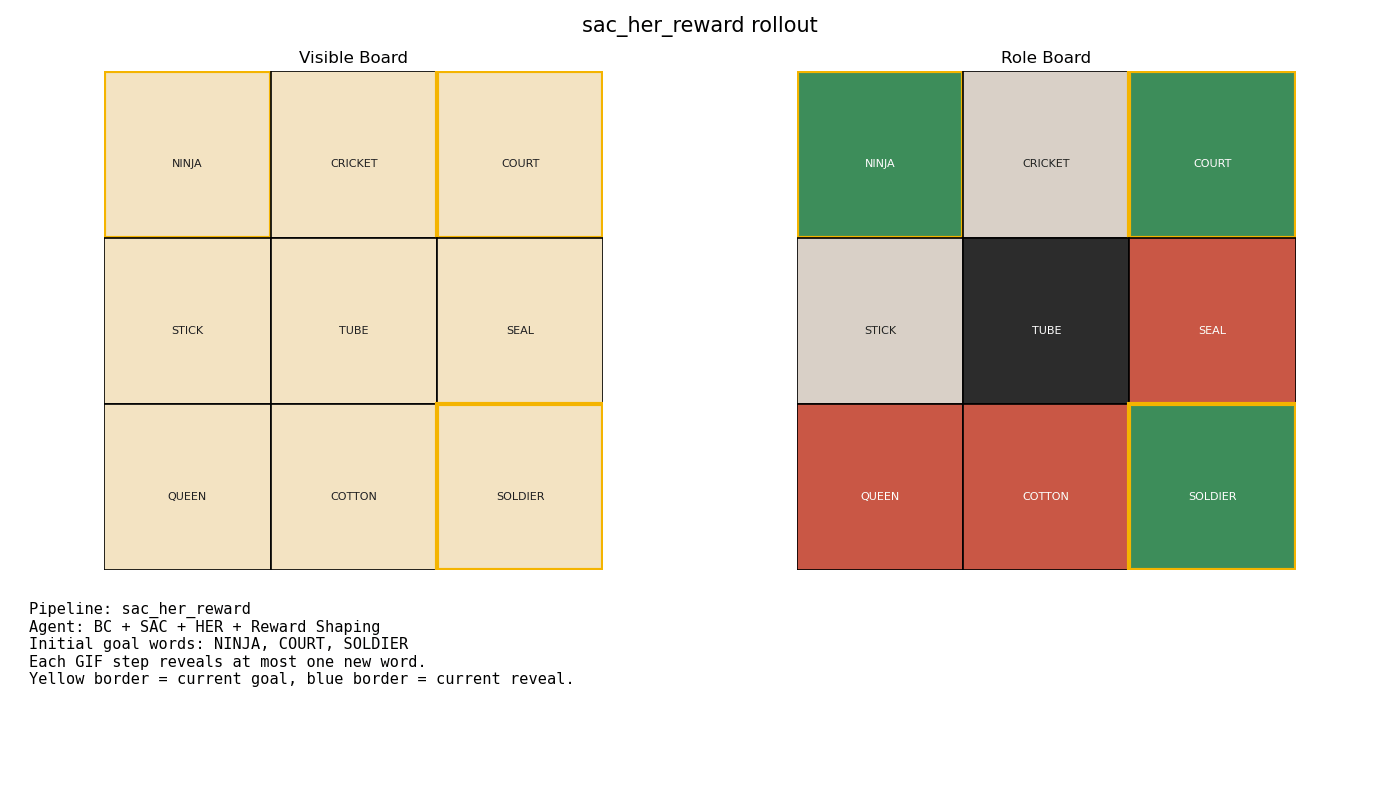

,pipeline,agent,reward_shaped_weight,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
0,sac_her_reward,BC + SAC + HER + Reward Shaping,1.0,18,0.0,1.0,7,-57.892,False,True,notebooks/artifacts/training_pipeline_rollout_...


,step,turn,reveal_in_turn,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,1,1,israeli,1,"NINJA, COURT, SOLDIER",SOLDIER,friendly,-1.089613,-1.089613,2,False,False
1,2,2,1,strict,1,"NINJA, COURT",STICK,neutral,-2.608083,-3.697696,2,False,False
2,3,3,1,certain,1,"NINJA, COURT",SEAL,opponent,-4.084331,-7.782027,2,False,False
3,4,4,1,above,1,"NINJA, COURT",NINJA,friendly,-1.039723,-8.821750,1,False,False
4,5,5,1,outer,1,COURT,QUEEN,opponent,-4.028744,-12.850495,1,False,False
5,6,6,1,other,1,COURT,COTTON,opponent,-4.019275,-16.869770,1,False,False
6,7,7,1,below,1,COURT,TUBE,assassin,-41.022443,-57.892213,1,False,True


In [9]:
runs = {name: run_pipeline_demo(name) for name in PIPELINES}

## Step 4. Organize the Final Conclusions

This table provides an overview of the three pipelines for quick comparison. If you want to switch agents later, you only need to add the corresponding pipeline or replace the builder, and the section below can still be reused.

In [10]:
comparison_df = pd.concat(
    [item["summary_df"] for item in runs.values()], ignore_index=True
)
comparison_df.sort_values(
    ["trace_won", "eval_win_rate", "trace_total_reward"],
    ascending=[False, False, False],
)

,pipeline,agent,reward_shaped_weight,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
0,greedy,Greedy,0.0,0,1.0,0.0,3,-2.000,True,False,notebooks/artifacts/training_pipeline_rollout_...
1,greedy_bc_pretrain,BC,0.0,18,0.0,1.0,3,-43.500,False,True,notebooks/artifacts/training_pipeline_rollout_...
2,sac_her,BC + SAC + HER,0.0,18,0.0,1.0,7,-57.500,False,True,notebooks/artifacts/training_pipeline_rollout_...
3,sac_her_reward,BC + SAC + HER + Reward Shaping,1.0,18,0.0,1.0,7,-57.892,False,True,notebooks/artifacts/training_pipeline_rollout_...


## Step 5. If you want to change the agent, where to suggest changes

- Training orchestration: `src/training/pipeline_registry.py`
- Shared env / config / demo collection: `src/training/pipeline_utils.py`
- GIF and rollout visualization: `src/training/rollout_visualizer.py`

As long as the new agent can provide `predict(...)` or `select_action(...)`, the main flow of this notebook usually doesn't need to be changed.